# Retail Sales Dataset — Product Sales & Revenue EDA

**Question:** A supermarket wants to analyze product sales based on
category, price, quantity sold, discount, and revenue. Perform EDA to
identify high-selling products and revenue patterns.

**Author:** Data Analytics Assignment
**Dataset:** `retail_sales.csv` (20 product records, 6 columns)


## Common EDA Tasks Checklist (per updated assessment rubric)

This notebook explicitly covers the following 8 standard EDA tasks:

1. **Number of rows and columns** — Task 1 & 2 section
2. **Data types of each column** — Task 1 & 2 section
3. **Missing values and duplicate values** — Task 3a / 3b / 3c sections
4. **Mean, median, minimum, maximum, and standard deviation** — Task 4 section
5. **Bar chart, histogram, scatter plot, and box plot** (plus pie chart, line
   chart, and heatmap as bonus visualizations) — Task 5a–5e sections
6. **Important patterns in the dataset** — Task 6 sections (group
   comparisons and correlation heatmap)
7. **4–5 observations based on EDA** — Task 7 section
8. **Short conclusion from the analysis** — Task 8 section

### Rubric Criteria Alignment (Weightage)

| Rubric Criteria | Weightage | Where it's covered |
|---|---|---|
| Dataset Understanding | 20 | Section 2 (dataset description, features, purpose) |
| Data Cleaning | 25 | Tasks 3a–3c (missing values, duplicates, inconsistent/incorrect entries) |
| Data Analysis and Statistical Summary | 20 | Task 4 (descriptive statistics) + Task 6 (patterns) |
| Data Visualization | 20 | Task 5a–5e (bar, pie, histogram, box, scatter, line, heatmap — all labeled) |
| Insight Generation and Reporting | 15 | Task 7 (observations) + Task 8 (conclusion) |


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', None)
print("Libraries imported successfully.")

def show_df(dframe, n=None):
    """Pretty-print a DataFrame (use IPython display() instead in Jupyter)."""
    print((dframe.head(n) if n else dframe).to_string())


Libraries imported successfully.


## 2. Load the Dataset

In [2]:
df = pd.read_csv("data/retail_sales.csv")
show_df(df, 20)


,Product_ID,Category,Price,Quantity_Sold,Discount,Revenue
0,PR01,Grocery,50,20,5,1000
1,PR02,Snacks,30,35,3,1050
2,PR03,Dairy,45,18,2,810
3,PR04,Fruits,60,25,5,1500
4,PR05,Vegetables,40,30,4,1200
5,PR06,Grocery,80,15,6,1200
6,PR07,Snacks,25,40,3,1000
7,PR08,Dairy,55,16,2,880
8,PR09,Fruits,70,22,5,1540
9,PR10,Vegetables,35,28,4,980


### Dataset Description

| Item | Detail |
|---|---|
| **Records (rows)** | 20 products |
| **Features (columns)** | 6 |
| **Product_ID** | Object (string) — unique identifier for each product |
| **Category** | Object (categorical) — product category (Grocery, Snacks, Dairy, Fruits, Vegetables) |
| **Price** | Integer — unit selling price (currency units) |
| **Quantity_Sold** | Integer — number of units sold |
| **Discount** | Integer — discount offered (percentage) |
| **Revenue** | Integer — total revenue generated by the product |

**Purpose & significance:** This dataset helps the supermarket understand
**which categories and products drive the most revenue**, how price and
discount relate to quantity sold, and whether promotional discounting is
actually paying off. These insights support **inventory planning,
pricing strategy, and promotion design** — e.g. deciding which categories
to stock more of, and whether discounts are effectively boosting volume.


## Task 1 & 2: Number of Rows/Columns and Data Types

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Column data types:")
print(df.dtypes)


Shape (rows, columns): (20, 6)

Column data types:
Product_ID         str
Category           str
Price            int64
Quantity_Sold    int64
Discount         int64
Revenue          int64
dtype: object


In [4]:
print("General info:")
df.info()


General info:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Product_ID     20 non-null     str  
 1   Category       20 non-null     str  
 2   Price          20 non-null     int64
 3   Quantity_Sold  20 non-null     int64
 4   Discount       20 non-null     int64
 5   Revenue        20 non-null     int64
dtypes: int64(4), str(2)
memory usage: 1.1 KB


## Task 3a: Missing Values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()
print("Total missing values in dataset:", df.isnull().sum().sum())


Missing values per column:
Product_ID       0
Category         0
Price            0
Quantity_Sold    0
Discount         0
Revenue          0
dtype: int64

Total missing values in dataset: 0


**Observation:** The dataset has **no missing values** in any column. No imputation is required.

## Task 3b: Duplicate Values

In [6]:
dup_rows = df.duplicated().sum()
dup_ids = df['Product_ID'].duplicated().sum()
print("Fully duplicated rows:", dup_rows)
print("Duplicated Product_IDs:", dup_ids)

before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Rows before: {before}, after de-duplication: {after}")


Fully duplicated rows: 0
Duplicated Product_IDs: 0
Rows before: 20, after de-duplication: 20


**Observation:** No duplicate rows or duplicate Product IDs were found; each product appears exactly once.

## Task 3c: Data Cleaning — Consistency Checks (Incorrect Entries & Range Validation)

In [7]:
# Standardise text fields
df['Product_ID'] = df['Product_ID'].str.strip()
df['Category'] = df['Category'].str.strip().str.title()

print("Unique categories:", df['Category'].unique().tolist())

# Range/sanity checks on numeric columns
checks = {
    'Price (> 0)':            (df['Price'] > 0).all(),
    'Quantity_Sold (>= 0)':    (df['Quantity_Sold'] >= 0).all(),
    'Discount (0-100%)':       df['Discount'].between(0, 100).all(),
    'Revenue (>= 0)':          (df['Revenue'] >= 0).all(),
}
for label, ok in checks.items():
    print(f"{label}: {'OK' if ok else 'OUT OF RANGE VALUES FOUND'}")

# Cross-field consistency check: does Revenue = Price x Quantity_Sold?
expected_revenue = df['Price'] * df['Quantity_Sold']
matches = (expected_revenue == df['Revenue']).all()
print()
print("Revenue == Price x Quantity_Sold for every row:", matches)

df['Category'] = df['Category'].astype('category')
print("Category column dtype now:", df['Category'].dtype)


Unique categories: ['Grocery', 'Snacks', 'Dairy', 'Fruits', 'Vegetables']
Price (> 0): OK
Quantity_Sold (>= 0): OK
Discount (0-100%): OK
Revenue (>= 0): OK

Revenue == Price x Quantity_Sold for every row: True
Category column dtype now: category


**Observation:** All numeric fields are within logical ranges, and every
row satisfies `Revenue = Price x Quantity_Sold` exactly. This means the
**`Revenue` column is gross revenue and does not have the `Discount`
already deducted from it** — `Discount` is recorded separately as a
percentage. This is an important data-quality finding: any analysis of
"actual" net revenue after discount would need to compute
`Revenue * (1 - Discount/100)` separately; it is not baked into the
existing `Revenue` figures.


## Task 4: Descriptive Statistics — Mean, Median, Min, Max, Std

In [8]:
num_cols = ['Price', 'Quantity_Sold', 'Discount', 'Revenue']
print("Descriptive statistics for numerical columns:")
show_df(df[num_cols].describe().round(2))


Descriptive statistics for numerical columns:


,Price,Quantity_Sold,Discount,Revenue
count,20.00,20.00,20.00,20.00
mean,54.00,24.00,4.00,1114.00
std,22.80,9.67,1.56,221.42
min,20.00,10.00,2.00,810.00
25%,35.00,17.50,3.00,972.50
50%,50.00,21.00,4.00,1050.00
75%,71.25,30.50,5.00,1200.00
max,100.00,45.00,7.00,1540.00


In [9]:
print("Additional statistics:")
summary = pd.DataFrame({
    'mean':   df[num_cols].mean(),
    'median': df[num_cols].median(),
    'std':    df[num_cols].std(),
    'skew':   df[num_cols].skew(),
})
show_df(summary.round(2))


Additional statistics:


,mean,median,std,skew
Price,54.0,50.0,22.80,0.42
Quantity_Sold,24.0,21.0,9.67,0.61
Discount,4.0,4.0,1.56,0.28
Revenue,1114.0,1050.0,221.42,0.85


## Task 5a: Bar Chart & Pie Chart — Categorical Analysis (Category)

In [10]:
cat_counts = df['Category'].value_counts()
print("Product count per category:")
print(cat_counts)


Product count per category:
Category
Dairy         4
Fruits        4
Grocery       4
Snacks        4
Vegetables    4
Name: count, dtype: int64


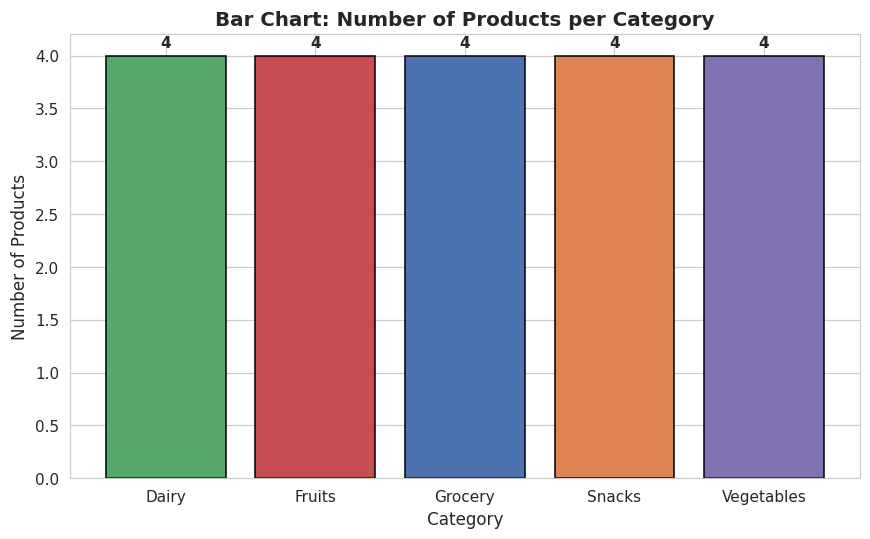

In [11]:
palette = {
    'Grocery': '#4C72B0', 'Snacks': '#DD8452', 'Dairy': '#55A868',
    'Fruits': '#C44E52', 'Vegetables': '#8172B2'
}
cat_colors = [palette[c] for c in cat_counts.index]

fig, ax = plt.subplots()
bars = ax.bar(cat_counts.index, cat_counts.values, color=cat_colors, edgecolor='black')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, str(int(b.get_height())),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Bar Chart: Number of Products per Category')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Products')
plt.tight_layout()
plt.show()


**Observation:** Every category (Grocery, Snacks, Dairy, Fruits, Vegetables) has exactly 4 products — the dataset is perfectly balanced across categories.

## Task 5b: Histogram & Box Plot — Numerical Distributions

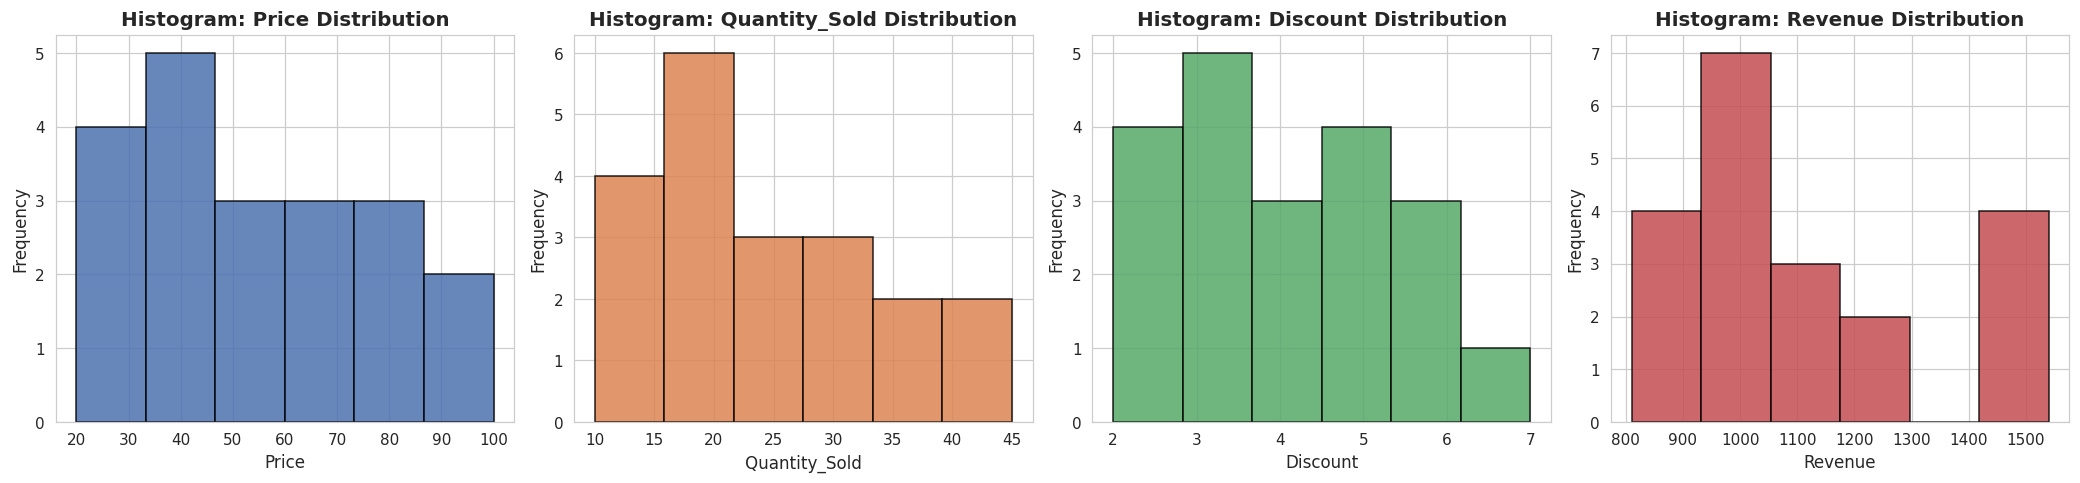

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
colors_hist = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, c in zip(axes, num_cols, colors_hist):
    ax.hist(df[col], bins=6, color=c, edgecolor='black', alpha=0.85)
    ax.set_title(f'Histogram: {col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


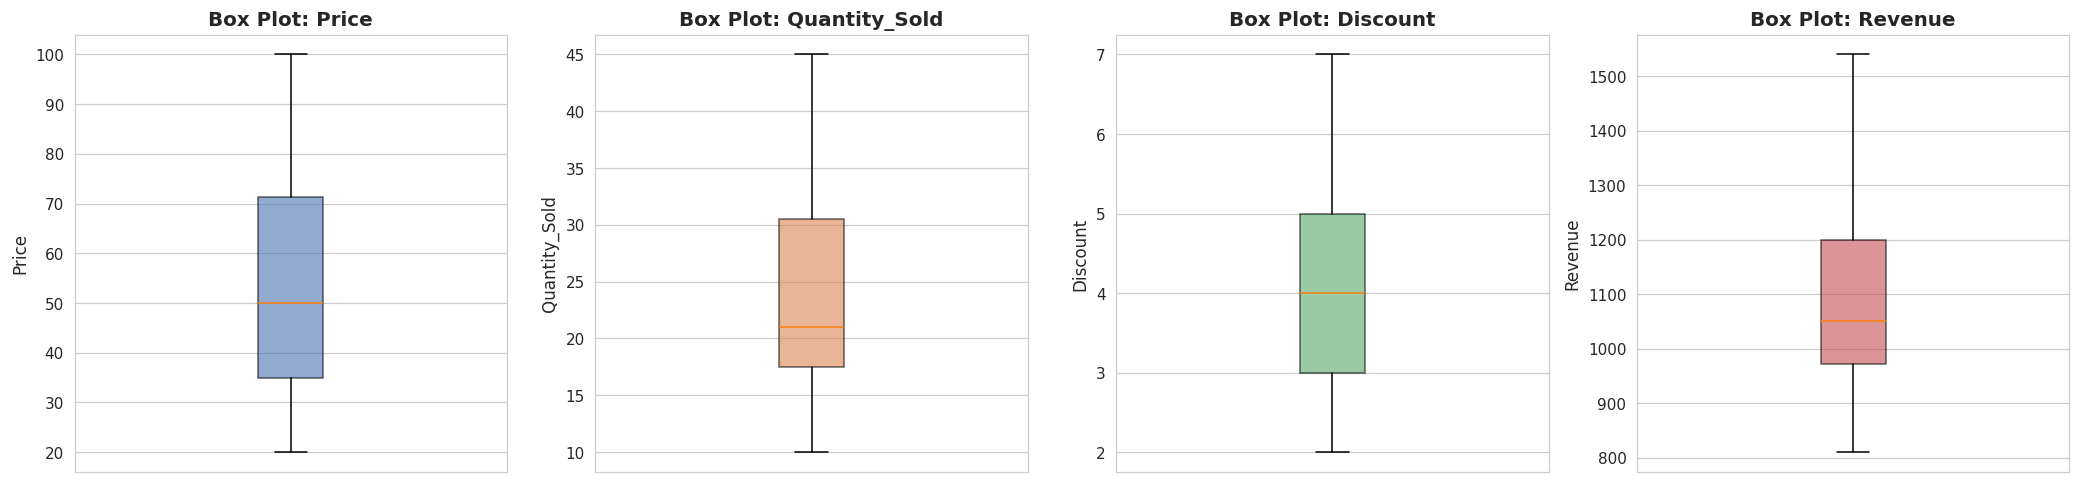

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, col, c in zip(axes, num_cols, colors_hist):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6))
    ax.set_title(f'Box Plot: {col}')
    ax.set_ylabel(col)
    ax.set_xticks([])

plt.tight_layout()
plt.show()


**Observation:** No extreme outliers are visible in Price, Quantity_Sold, Discount or Revenue — all four show reasonably symmetric spreads typical of everyday supermarket products.

## Task 6a: Important Patterns — Revenue & Sales by Category

In [14]:
cat_summary = df.groupby('Category', observed=True).agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity_Sold', 'sum'),
    Avg_Price=('Price', 'mean'),
    Avg_Discount=('Discount', 'mean'),
).round(2).sort_values('Total_Revenue', ascending=False)
show_df(cat_summary)


,Total_Revenue,Total_Quantity,Avg_Price,Avg_Discount
Category,,,,
Fruits,5980,85,71.25,5.25
Vegetables,4400,119,37.50,3.75
Grocery,4280,57,80.00,6.00
Snacks,4070,152,27.50,2.75
Dairy,3550,67,53.75,2.25


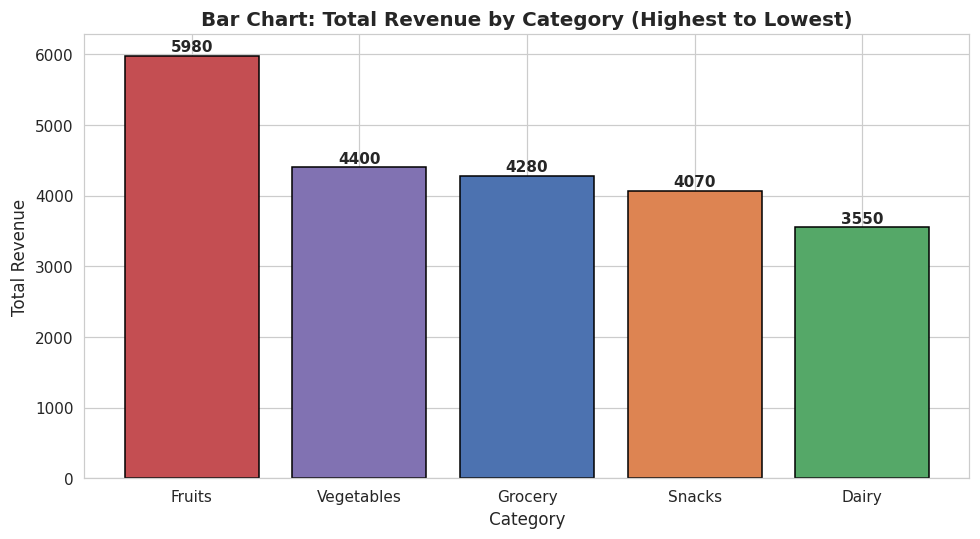

In [15]:
fig, ax = plt.subplots(figsize=(9,5))
cats_sorted = cat_summary.index
bars = ax.bar(cats_sorted, cat_summary['Total_Revenue'],
              color=[palette[c] for c in cats_sorted], edgecolor='black')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, f"{int(b.get_height())}",
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Bar Chart: Total Revenue by Category (Highest to Lowest)')
ax.set_xlabel('Category')
ax.set_ylabel('Total Revenue')
plt.tight_layout()
plt.show()


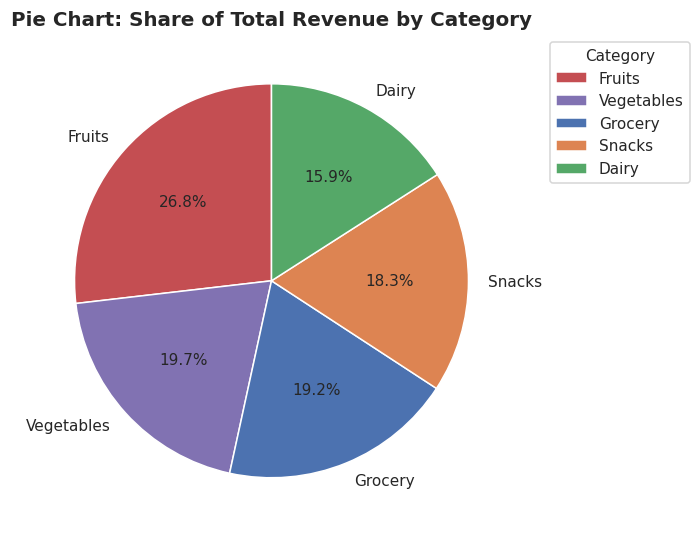

In [16]:
fig, ax = plt.subplots()
ax.pie(cat_summary['Total_Revenue'], labels=cat_summary.index, autopct='%1.1f%%',
       colors=[palette[c] for c in cat_summary.index], startangle=90,
       wedgeprops={'edgecolor':'white'})
ax.set_title('Pie Chart: Share of Total Revenue by Category')
ax.legend(cat_summary.index, title="Category", loc="best", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


**Observation:** `Fruits` generates the highest total category revenue,
followed by `Vegetables`, `Grocery`, and `Snacks`; `Dairy` generates the
least total revenue among the five categories — useful information for
shelf-space and stocking decisions.


## Task 5e: Bar Chart — Top-Selling Products (Bonus)

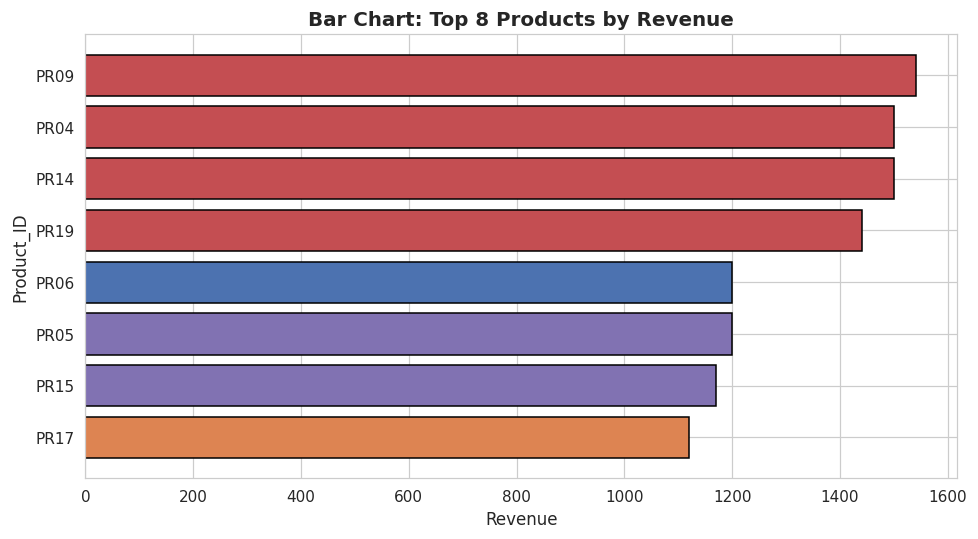

In [17]:
top_revenue = df.sort_values('Revenue', ascending=False).head(8)

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(top_revenue['Product_ID'][::-1], top_revenue['Revenue'][::-1],
               color=[palette[c] for c in top_revenue['Category'][::-1]], edgecolor='black')
ax.set_title('Bar Chart: Top 8 Products by Revenue')
ax.set_xlabel('Revenue')
ax.set_ylabel('Product_ID')
plt.tight_layout()
plt.show()


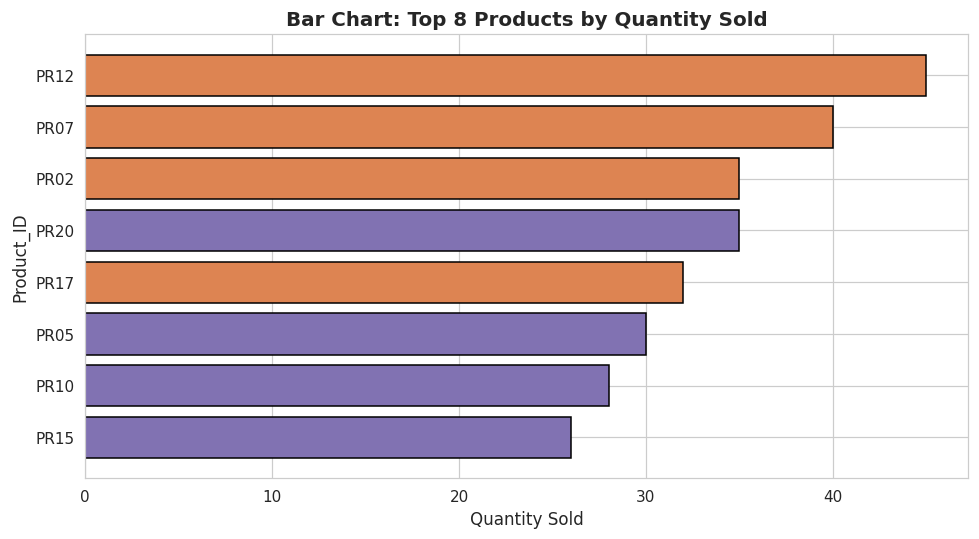

In [18]:
top_qty = df.sort_values('Quantity_Sold', ascending=False).head(8)

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(top_qty['Product_ID'][::-1], top_qty['Quantity_Sold'][::-1],
               color=[palette[c] for c in top_qty['Category'][::-1]], edgecolor='black')
ax.set_title('Bar Chart: Top 8 Products by Quantity Sold')
ax.set_xlabel('Quantity Sold')
ax.set_ylabel('Product_ID')
plt.tight_layout()
plt.show()


**Observation:** The highest-revenue products (e.g. PR04, PR09, PR14, PR19 — all Fruits) are not always the highest-volume products (e.g. PR12, PR07, PR17 — Snacks sell in the largest quantities but at low unit price), showing that **volume leaders and revenue leaders are different products**.

## Task 5c: Scatter Plot — Bivariate Relationships

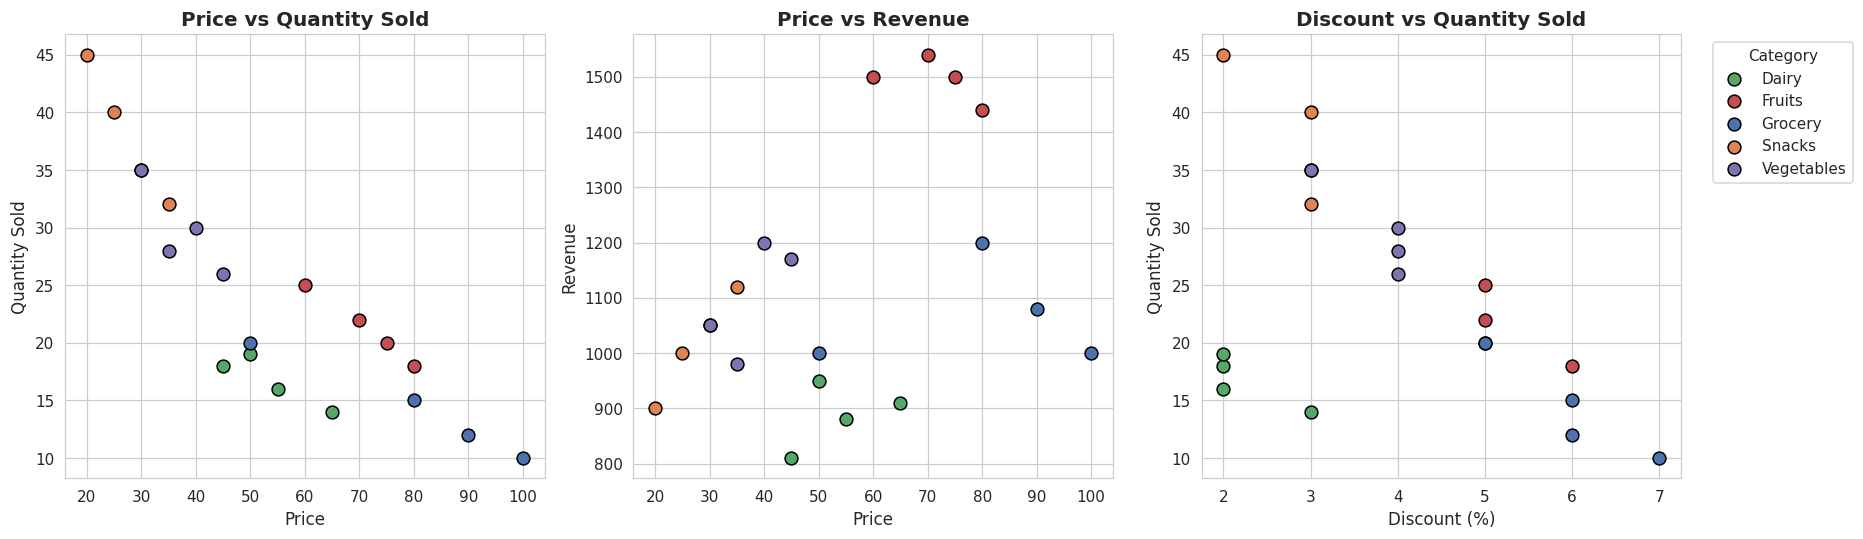

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for cat in df['Category'].cat.categories:
    subset = df[df['Category'] == cat]
    axes[0].scatter(subset['Price'], subset['Quantity_Sold'], label=cat,
                     color=palette[cat], edgecolor='black', s=70)
    axes[1].scatter(subset['Price'], subset['Revenue'], label=cat,
                     color=palette[cat], edgecolor='black', s=70)
    axes[2].scatter(subset['Discount'], subset['Quantity_Sold'], label=cat,
                     color=palette[cat], edgecolor='black', s=70)

axes[0].set_title('Price vs Quantity Sold')
axes[0].set_xlabel('Price'); axes[0].set_ylabel('Quantity Sold')

axes[1].set_title('Price vs Revenue')
axes[1].set_xlabel('Price'); axes[1].set_ylabel('Revenue')

axes[2].set_title('Discount vs Quantity Sold')
axes[2].set_xlabel('Discount (%)'); axes[2].set_ylabel('Quantity Sold')
axes[2].legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


**Observation:** `Price` and `Quantity_Sold` show a clear **negative
relationship** — cheaper products sell in higher volumes, as expected.
`Price` and `Revenue` show a positive relationship despite lower volumes
at high prices, meaning higher-priced items still generate strong revenue
per unit. `Discount` and `Quantity_Sold` show a **moderate negative**
trend in this sample — products with bigger discounts are not the
higher-volume sellers, which is the opposite of what a "discounts drive
volume" assumption would predict.


## Task 5d: Line Chart — Trend Analysis (Bonus Visualization)

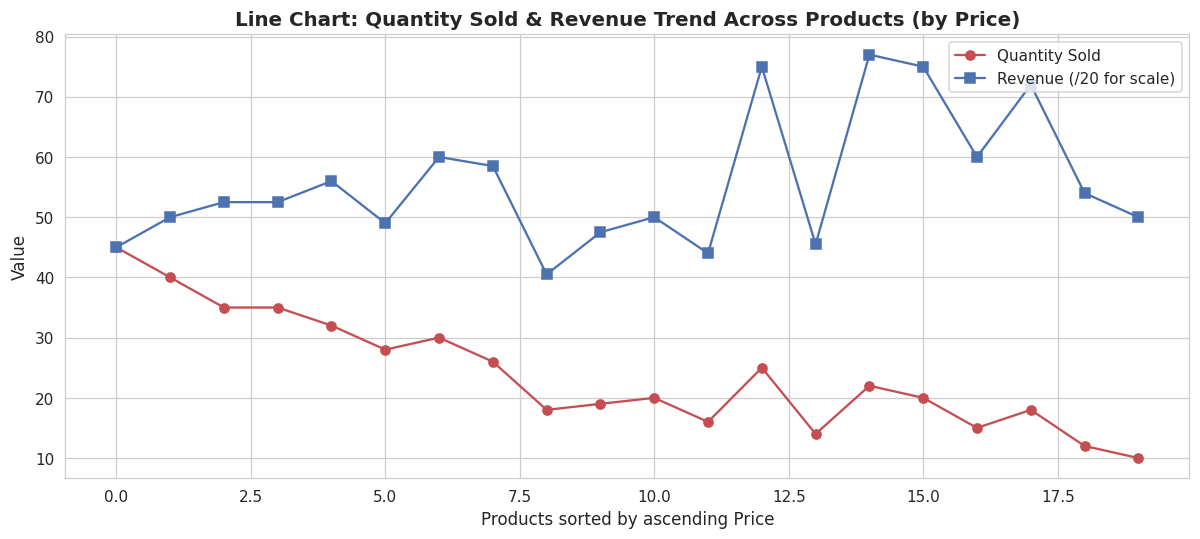

In [20]:
trend_df = df.sort_values('Price').reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(trend_df.index, trend_df['Quantity_Sold'], marker='o', color='#C44E52', label='Quantity Sold')
ax1.plot(trend_df.index, trend_df['Revenue']/20, marker='s', color='#4C72B0', label='Revenue (/20 for scale)')
ax1.set_xlabel('Products sorted by ascending Price')
ax1.set_ylabel('Value')
ax1.set_title('Line Chart: Quantity Sold & Revenue Trend Across Products (by Price)')
ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()


**Observation:** As products are ordered by increasing price, quantity sold trends downward while revenue stays relatively stable/increases — confirming that higher unit prices compensate for lower volumes in this product mix.

## Task 6b: Important Patterns — Correlation Heatmap

In [21]:
corr_matrix = df[num_cols].corr().round(2)
show_df(corr_matrix)


,Price,Quantity_Sold,Discount,Revenue
Price,1.00,-0.87,0.79,0.39
Quantity_Sold,-0.87,1.00,-0.51,-0.08
Discount,0.79,-0.51,1.00,0.58
Revenue,0.39,-0.08,0.58,1.00


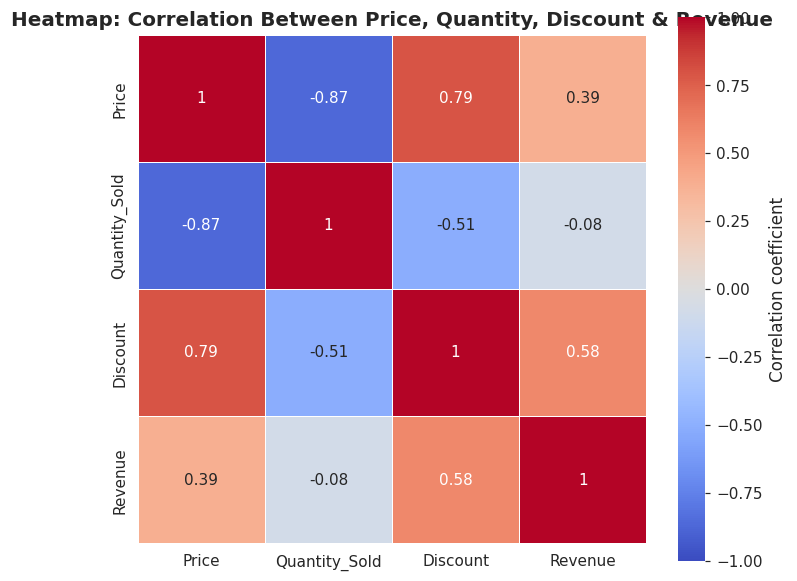

In [22]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation coefficient'}, ax=ax)
ax.set_title('Heatmap: Correlation Between Price, Quantity, Discount & Revenue')
plt.tight_layout()
plt.show()


**Observation:** `Price` and `Quantity_Sold` are **strongly negatively
correlated** (higher price, lower volume), while `Price` and `Revenue`
are **positively correlated** — revenue is driven more by price level
than by volume in this dataset. `Discount` is **positively correlated
with Price** and **negatively correlated with Quantity_Sold** — in this
sample, bigger discounts tend to sit on higher-priced, lower-volume
products rather than on the high-turnover items, so discounting here
does not clearly stimulate extra volume.


## Task 7: Observations (4–5 Key Observations)

1. **Dataset is clean**: no missing values, no duplicate records, and all
   values fall within logical ranges.
2. **Data-quality finding**: `Revenue = Price x Quantity_Sold` holds
   exactly for every row — `Revenue` is **gross revenue** and does not
   yet reflect the `Discount` percentage.
3. **Fruits generates the highest total category revenue**, followed by
   Vegetables, Grocery, and Snacks; **Dairy generates the least**, despite
   every category having the same number of products (4).
4. **Price and Quantity_Sold are strongly negatively correlated** —
   cheaper products (Snacks) sell the highest volumes, while pricier
   products (Fruits, Grocery) generate more revenue per unit.
5. **Discount is positively correlated with Price and negatively with
   Quantity_Sold** — bigger discounts sit on pricier, lower-volume
   products rather than driving extra sales volume.

## Task 8: Conclusion

Revenue in this store is driven more by price level than by sales
volume, and blanket discounting does not appear to be an effective
volume driver in this sample. The supermarket should prioritise shelf
space and stocking for high-revenue categories like Fruits, reconsider
broad discounts in favour of more targeted promotions, and start
tracking true net revenue (`Revenue x (1 - Discount/100)`) to see the
real cost of discounting alongside gross sales.
